# Project: Logistic Regression from Scratch

## 0. Overview

**Problem statement:** Logistic regression is the foundational classification model. Build it from nothing: sigmoid activation *(ch074)*, binary cross-entropy loss, gradient computation via backpropagation *(ch216)*, and training via mini-batch gradient descent *(ch227)*. Validate against scikit-learn.

**Concepts applied:**
- Sigmoid function (ch074 — Sigmoid Functions)
- Backpropagation and chain rule (ch215, ch216)
- Gradient-based learning (ch227)
- Probability and log-likelihood (Part VIII — Probability)

**Expected output:** Decision boundary plots, ROC/AUC curve *(ch222)*, training loss curve.

**Difficulty:** Intermediate–Advanced. Estimated time: 60–90 min.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("Setup complete.")


Setup complete.


## 1. Setup — Generate Classification Data

Training: (400, 2), Test: (100, 2)
Class balance: 50.50% positive in train


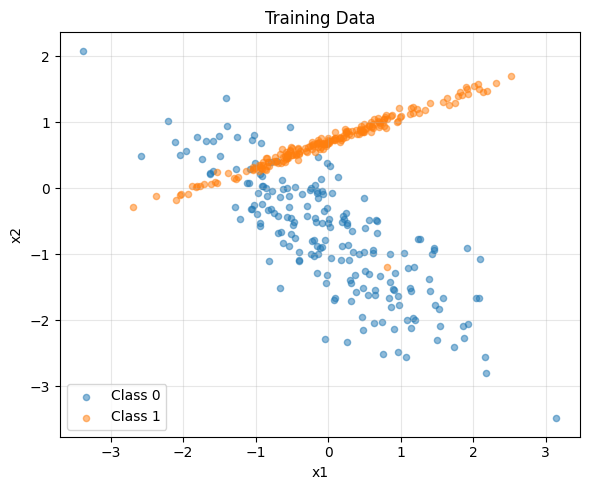

In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=500, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardise features (important for gradient descent stability)
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
X_train = (X_train - mu) / sigma
X_test  = (X_test  - mu) / sigma

print(f"Training: {X_train.shape}, Test: {X_test.shape}")
print(f"Class balance: {y_train.mean():.2%} positive in train")

# Visualise raw data
plt.figure(figsize=(6, 5))
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], alpha=0.5, label='Class 0', s=20)
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], alpha=0.5, label='Class 1', s=20)
plt.xlabel('x1'); plt.ylabel('x2'); plt.title('Training Data')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('ch230_data.png', dpi=100); plt.show()


## 2. Stage 1 — Model Definition and Forward Pass

In [3]:
def sigmoid(z): return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def forward(X, w, b):
    z = X @ w + b          # linear combination
    p = sigmoid(z)          # probability
    return p

def binary_cross_entropy(p, y, eps=1e-12):
    # BCE = -mean[ y*log(p) + (1-y)*log(1-p) ]
    return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

# Initialise
w = np.zeros(X_train.shape[1])
b = 0.0

p_init = forward(X_train, w, b)
print(f"Initial predictions (should be ~0.5): min={p_init.min():.3f}, max={p_init.max():.3f}")
print(f"Initial BCE loss: {binary_cross_entropy(p_init, y_train):.4f}  (log(2) = {np.log(2):.4f})")


Initial predictions (should be ~0.5): min=0.500, max=0.500
Initial BCE loss: 0.6931  (log(2) = 0.6931)


## 3. Stage 2 — Gradient Derivation and Backward Pass

For logistic regression the gradient of BCE w.r.t. w is elegantly:

```
dL/dw = (1/n) * X^T * (sigma(Xw+b) - y)
dL/db = mean(sigma(Xw+b) - y)
```

This follows from the chain rule *(ch215)* applied through sigmoid and BCE.

In [4]:
def gradients(X, y, w, b):
    n = len(y)
    p = forward(X, w, b)
    err = p - y                   # (n,)
    dw = (1/n) * X.T @ err        # (d,)
    db = np.mean(err)              # scalar
    return dw, db

def train(X_train, y_train, lr=0.1, n_epochs=300, batch_size=32):
    n, d = X_train.shape
    w = np.zeros(d)
    b = 0.0
    losses = []
    for epoch in range(n_epochs):
        idx = np.random.permutation(n)
        for start in range(0, n, batch_size):
            batch = idx[start:start+batch_size]
            dw, db = gradients(X_train[batch], y_train[batch], w, b)
            w -= lr * dw
            b -= lr * db
        p = forward(X_train, w, b)
        losses.append(binary_cross_entropy(p, y_train))
    return w, b, losses

w, b, loss_hist = train(X_train, y_train, lr=0.5, n_epochs=400, batch_size=32)
print(f"Trained weights: {w}")
print(f"Trained bias: {b:.4f}")
print(f"Final training loss: {loss_hist[-1]:.4f}")


Trained weights: [0.46567186 3.43949844]
Trained bias: -0.3246
Final training loss: 0.3233


## 4. Stage 3 — Evaluation and Decision Boundary

Train accuracy: 0.8750
Test  accuracy: 0.8800


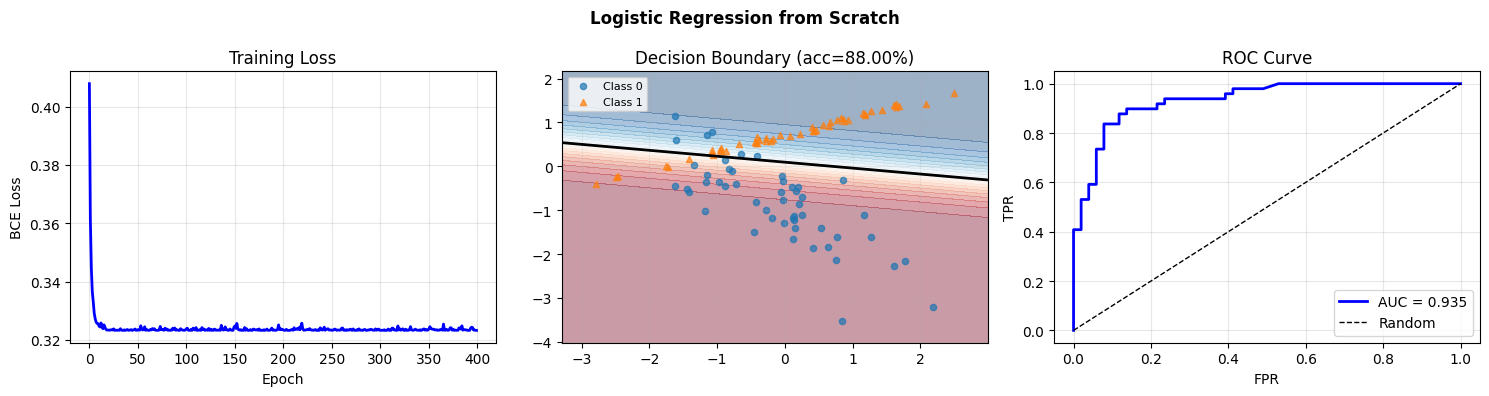


Scikit-learn accuracy: 0.8800  (our model: 0.8800)


In [6]:
def accuracy(X, y, w, b, threshold=0.5):
    p = forward(X, w, b)
    return np.mean((p >= threshold) == y)

acc_train = accuracy(X_train, y_train, w, b)
acc_test  = accuracy(X_test,  y_test,  w, b)
print(f"Train accuracy: {acc_train:.4f}")
print(f"Test  accuracy: {acc_test:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curve
axes[0].plot(loss_hist, 'b', lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Training Loss'); axes[0].grid(True, alpha=0.3)

# Decision boundary
x1_r = np.linspace(X_test[:, 0].min()-0.5, X_test[:, 0].max()+0.5, 200)
x2_r = np.linspace(X_test[:, 1].min()-0.5, X_test[:, 1].max()+0.5, 200)
XX, YY = np.meshgrid(x1_r, x2_r)
Z = forward(np.c_[XX.ravel(), YY.ravel()], w, b).reshape(XX.shape)
axes[1].contourf(XX, YY, Z, levels=20, cmap='RdBu', alpha=0.4)
axes[1].contour(XX, YY, Z, levels=[0.5], colors='black', linewidths=2)
axes[1].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], alpha=0.7, label='Class 0', s=20)
axes[1].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], alpha=0.7, label='Class 1', s=20, marker='^')
axes[1].set_title(f'Decision Boundary (acc={acc_test:.2%})'); axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2)

# ROC curve (introduced in ch222 — Area Under Curve)
p_test = forward(X_test, w, b)
thresholds = np.linspace(0, 1, 300)
tprs, fprs = [], []
for t in thresholds:
    pred = (p_test >= t)
    tp = np.sum(pred & (y_test == 1)) / max(np.sum(y_test == 1), 1)
    fp = np.sum(pred & (y_test == 0)) / max(np.sum(y_test == 0), 1)
    tprs.append(tp); fprs.append(fp)

auc = np.trapezoid(tprs[::-1], fprs[::-1])
axes[2].plot(fprs, tprs, 'b', lw=2, label=f'AUC = {auc:.3f}')
axes[2].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('ROC Curve'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Logistic Regression from Scratch', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('ch230_logistic.png', dpi=100); plt.show()

# Sklearn validation
from sklearn.linear_model import LogisticRegression
sk = LogisticRegression(random_state=42).fit(X_train, y_train)
print(f"\nScikit-learn accuracy: {sk.score(X_test, y_test):.4f}  (our model: {acc_test:.4f})")


## 5. Results & Reflection

**What was built:** Binary classification via logistic regression — forward pass, BCE loss, gradient descent, decision boundary, and ROC/AUC evaluation.

**What math made it possible:**
- Sigmoid function *(ch074)*: maps linear output to probabilities in [0,1]
- Chain rule *(ch215)*: gradient of BCE through sigmoid simplifies to `p - y`
- Mini-batch SGD *(ch227)*: stochastic gradient accumulation for scalable training
- AUC as area under ROC curve *(ch222)*: integral of TPR as function of FPR

**Extension challenges:**
1. Implement L2 regularisation: add `lambda * sum(w^2)` to the loss and `lambda * w` to the gradient. Plot decision boundaries as lambda increases.
2. Extend to multiclass using softmax + categorical cross-entropy.
3. Replace gradient descent with Newton's method (second-order): use the Hessian `X^T * diag(p*(1-p)) * X` to converge in fewer steps.